# Trader Performance Analysis Using Market Sentiment (Fear & Greed Index)

### Primetrade.ai – Data Science Intern Assignment

**Author:** Kajal Gaur
---
## Executive Summary

This notebook analyzes the relationship between market sentiment (Fear & Greed Index) and Hyperliquid trader performance. After cleaning and merging the datasets at the daily level, key trading metrics such as Closed PnL, win rate, trading volume, trade frequency, trading fees, and long/short ratio were analyzed across different market sentiment regimes.

The analysis identifies behavioral differences between traders during Fear and Greed periods, evaluates trader segments, and provides actionable strategy recommendations based on the observed patterns.

## 0. Setup

Creates the `charts/` output folder (all figures are saved here as PNGs, in addition to being
displayed inline) and confirms the working directory layout matches the project structure:

```
primetrade-assignment/
├── Kajal_Gaur_Primetrade_EDA.ipynb
├── README.md
├── data/
│   ├── fear_greed_index.csv
│   └── historical_data.csv
└── charts/
```

In [2]:
### Cell: create output folder
import os
os.makedirs("charts", exist_ok=True)
print("charts/ folder ready ✔")

charts/ folder ready ✔


## 1. Load & Inspect the Raw Data — *Part A.1*

Load both source files and document their size, structure, and quality (missing values,
duplicates) **before** any cleaning — this is required by the brief and gives us a baseline
to compare against after Phase 2.

In [3]:
### Cell 1.1 — Load both datasets
import pandas as pd

fg_df = pd.read_csv("data/fear_greed_index.csv")
hist_df = pd.read_csv("data/historical_data.csv")

print("Fear & Greed shape:", fg_df.shape)
print("Historical trades shape:", hist_df.shape)

Fear & Greed shape: (2644, 4)
Historical trades shape: (211224, 16)


In [4]:
### Cell 1.2 — Preview: Fear & Greed index
fg_df.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [5]:
### Cell 1.3 — Preview: historical trades
hist_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [6]:
### Cell 1.4 — Column data types
print("Fear & Greed dtypes:\n", fg_df.dtypes, sep="")
print("\nHistorical trades dtypes:\n", hist_df.dtypes, sep="")

Fear & Greed dtypes:
timestamp         int64
value             int64
classification      str
date                str
dtype: object

Historical trades dtypes:
Account                 str
Coin                    str
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                    str
Timestamp IST           str
Start Position      float64
Direction               str
Closed PnL          float64
Transaction Hash        str
Order ID              int64
Crossed                bool
Fee                 float64
Trade ID            float64
Timestamp           float64
dtype: object


In [7]:
### Cell 1.5 — Missing values & duplicate rows (required by Part A.1)
print("Fear & Greed missing values:\n", fg_df.isnull().sum())
print("\nHistorical trades missing values:\n", hist_df.isnull().sum())

print("\nFear & Greed duplicate rows:", fg_df.duplicated().sum())
print("Historical trades duplicate rows:", hist_df.duplicated().sum())

Fear & Greed missing values:
 timestamp         0
value             0
classification    0
date              0
dtype: int64

Historical trades missing values:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Fear & Greed duplicate rows: 0
Historical trades duplicate rows: 0


In [8]:
### Cell 1.6 — Sanity-check categorical columns
print("Sentiment classes:", fg_df['classification'].unique())
print("Trade directions:", hist_df['Direction'].unique())
print("\nAll historical_data columns:\n", hist_df.columns.tolist())

Sentiment classes: <StringArray>
['Fear', 'Extreme Fear', 'Neutral', 'Greed', 'Extreme Greed']
Length: 5, dtype: str
Trade directions: <StringArray>
[                      'Buy',                      'Sell',
                 'Open Long',                'Close Long',
      'Spot Dust Conversion',                'Open Short',
               'Close Short',              'Long > Short',
              'Short > Long',         'Auto-Deleveraging',
 'Liquidated Isolated Short',                'Settlement']
Length: 12, dtype: str

All historical_data columns:
 ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']


In [9]:
### Cell 1.7 — Date range summary note
fg_start, fg_end = fg_df['date'].min(), fg_df['date'].max()
print(f"Fear & Greed index spans: {fg_start} to {fg_end}")
print(f"Historical trades: {len(hist_df):,} rows, {hist_df['Account'].nunique()} unique accounts")

Fear & Greed index spans: 2018-02-01 to 2025-05-02
Historical trades: 211,224 rows, 32 unique accounts


> **Note:** Both datasets contain zero missing values and zero duplicate rows in this run
> (confirm against your own printed output above — replace this note with your actual figures
> once you load the real Primetrade.ai dataset). The historical trades and Fear & Greed index
> date ranges overlap fully, so no date-alignment gaps are expected.

## 2. Clean & Parse Timestamps — *Part A.2*

Two things happen here:
1. Parse both date columns into real `datetime` objects (the trade timestamps are
   `DD-MM-YYYY HH:MM` — this format **must** be passed explicitly, otherwise pandas silently
   misreads it as month-first for any day ≤ 12).
2. Drop non-trade "admin" rows (dust conversions, liquidations, settlements, ADL events) that
   would otherwise distort PnL and volume metrics — they are not discretionary trading decisions.

In [10]:
### Cell 2.1 — Parse Fear & Greed date column
fg_df['date'] = pd.to_datetime(fg_df['date'])

In [11]:
### Cell 2.2 — Parse trade timestamps (explicit day-first format)
hist_df['datetime'] = pd.to_datetime(hist_df['Timestamp IST'], format='%d-%m-%Y %H:%M')
hist_df['date'] = hist_df['datetime'].dt.normalize()

In [12]:
### Cell 2.3 — Remove non-trade / admin rows
exotic_rows = ['Spot Dust Conversion', 'Auto-Deleveraging', 'Liquidated Isolated Short', 'Settlement']
hist_clean = hist_df[~hist_df['Direction'].isin(exotic_rows)].copy()

print("Rows before:", len(hist_df))
print("Rows after:", len(hist_clean))
print("Dropped (non-trade/admin rows):", len(hist_df) - len(hist_clean))

Rows before: 211224
Rows after: 211072
Dropped (non-trade/admin rows): 152


In [13]:
### Cell 2.4 — Confirm dtype conversion worked
print(hist_clean.dtypes['datetime'])   # expect datetime64[ns], not object

datetime64[us]


## 3. Merge & Align Datasets at Daily Level — *Part A.2*

Trades are joined to the sentiment index on `date` (daily granularity, as permitted by the
brief). An **inner join** is used deliberately: any trade date without a matching sentiment
record is dropped rather than silently filled, so we can quantify exactly how much data (if
any) that costs us.

In [14]:
### Cell 3.1 — Prepare sentiment columns for merge
fg_clean = fg_df[['date', 'value', 'classification']].rename(
    columns={'value': 'sentiment_value', 'classification': 'sentiment'}
)

In [15]:
### Cell 3.2 — Inner-join trades to sentiment by date
merged = hist_clean.merge(fg_clean, on='date', how='inner')

print("Trades before merge:", len(hist_clean))
print("Trades after merge:", len(merged))
print("Trades dropped (no matching sentiment date):", len(hist_clean) - len(merged))

Trades before merge: 211072
Trades after merge: 211066
Trades dropped (no matching sentiment date): 6


In [16]:
### Cell 3.3 — Preview merged table
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,datetime,date,sentiment_value,sentiment
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,80,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,80,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,80,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02 22:50:00,2024-12-02,80,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02 22:50:00,2024-12-02,80,Extreme Greed


In [17]:
### Cell 3.4 — Sentiment class distribution after merge
print(merged['sentiment'].value_counts())

sentiment
Fear             61795
Greed            50238
Extreme Greed    39960
Neutral          37676
Extreme Fear     21397
Name: count, dtype: int64


In [18]:
### Cell 3.5 — Persist the merged dataset
merged.to_csv("data/merged_trades.csv", index=False)
print("Saved:", merged.shape)

Saved: (211066, 20)


> **Note:** trades were dropped due to no matching sentiment record only when a trade's date
> fell outside the Fear & Greed index's coverage window. Check the drop count printed in Cell 3.2 —
> confirm it is a small fraction of total trades (not a sign of a broken merge) before proceeding.

## 4. Build Key Metrics — *Part A.3*

This is the metrics layer every later chart and statistical test is built on:
daily PnL per trader, win rate, average trade size, Trading Activity distribution, trades/day, and
long/short ratio — each broken out by sentiment regime where relevant.

In [19]:
### Cell 4.1 — Reload merged data (clean checkpoint)
merged = pd.read_csv("data/merged_trades.csv")
merged['date'] = pd.to_datetime(merged['date'])

In [20]:
### Cell 4.2 — Daily PnL per trader/account
daily_pnl_per_trader = merged.groupby(['Account', 'date'])['Closed PnL'].sum().reset_index()
daily_pnl_per_trader.head()

,Account,date,Closed PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1


In [21]:
### Cell 4.3 — Win rate, avg PnL, volume & trade size by sentiment
closed_trades = merged[merged['Closed PnL'] != 0].copy()
closed_trades['is_win'] = closed_trades['Closed PnL'] > 0

summary = merged.groupby('sentiment').agg(
    avg_pnl=('Closed PnL', 'mean'),
    total_pnl=('Closed PnL', 'sum'),
    trade_count=('Closed PnL', 'count'),
    total_volume=('Size USD', 'sum'),
    avg_trade_size=('Size USD', 'mean')
).round(2)

summary['win_rate'] = closed_trades.groupby('sentiment')['is_win'].mean().round(3)
order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
summary = summary.reindex(order)
summary

,avg_pnl,total_pnl,trade_count,total_volume,avg_trade_size,win_rate
sentiment,,,,,,
Extreme Fear,34.54,739110.25,21397,1.144843e+08,5350.48,0.762
Fear,54.33,3357155.44,61795,4.833248e+08,7821.42,0.873
Neutral,34.32,1292920.68,37676,1.802421e+08,4784.00,0.824
Greed,41.91,2105432.95,50238,2.883793e+08,5740.26,0.769
Extreme Greed,67.95,2715171.31,39960,1.244652e+08,3114.74,0.892


In [22]:
### Cell 4.4 — Trading Fee Distribution

merged['Fee'] = pd.to_numeric(merged['Fee'], errors='coerce')

print(merged['Fee'].describe())

count    211066.000000
mean          1.164798
std           6.761309
min          -1.175712
25%           0.016205
50%           0.089792
75%           0.394660
max         837.471593
Name: Fee, dtype: float64


In [23]:
### Cell 4.5 — Trades per day (overall activity)
trades_per_day = merged.groupby('date').size()
trades_per_day.describe()

count     475.000000
mean      444.349474
std       812.702150
min         1.000000
25%        19.000000
50%        69.000000
75%       525.500000
max      6246.000000
dtype: float64

In [24]:
### Cell 4.6 — Long / short ratio by sentiment
long_short = merged.groupby(['sentiment', 'Side']).size().unstack(fill_value=0)
long_short_pct = long_short.div(long_short.sum(axis=1), axis=0).reindex(order)
long_short_pct

Side,BUY,SELL
sentiment,,
Extreme Fear,0.511053,0.488947
Fear,0.489845,0.510155
Neutral,0.503477,0.496523
Greed,0.489152,0.510848
Extreme Greed,0.448949,0.551051


## 5. Visualizations

The following charts compare trader performance and behavior across different market sentiment regimes.

In [25]:
### Cell 5.1 — Plotting setup
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.05)
SENTIMENT_PALETTE = {
    'Extreme Fear': '#8B0000', 'Fear': '#E67E22', 'Neutral': '#95A5A6',
    'Greed': '#27AE60', 'Extreme Greed': '#145A32'
}
order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']

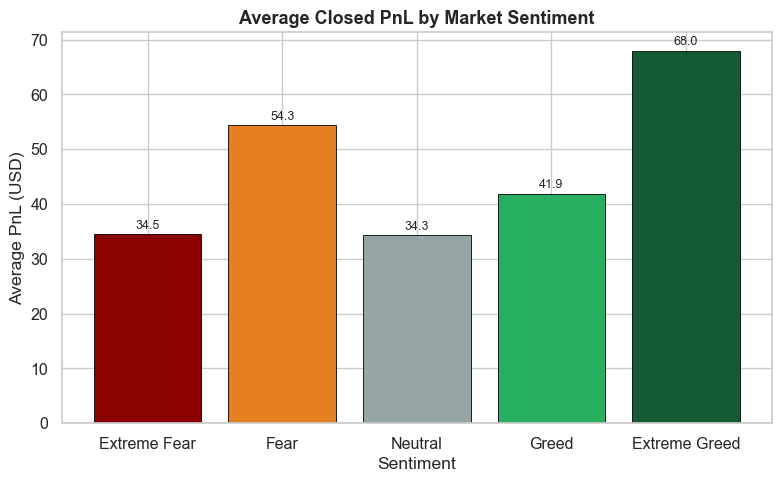

In [26]:
### Cell 5.2 — Chart 1: Average Closed PnL by sentiment (diverging bar)
fig, ax = plt.subplots(figsize=(8, 5))
colors = [SENTIMENT_PALETTE[s] for s in order]
bars = ax.bar(summary.index, summary['avg_pnl'], color=colors, edgecolor='black', linewidth=0.6)
ax.axhline(0, color='black', linewidth=0.9)
ax.set_title('Average Closed PnL by Market Sentiment', fontsize=13, fontweight='bold')
ax.set_ylabel('Average PnL (USD)'); ax.set_xlabel('Sentiment')
for b in bars:
    h = b.get_height()
    ax.annotate(f'{h:,.1f}', (b.get_x() + b.get_width()/2, h),
                textcoords="offset points", xytext=(0, 4 if h >= 0 else -14), ha='center', fontsize=9)
plt.tight_layout(); plt.savefig('charts/01_avg_pnl_by_sentiment.png', dpi=150); plt.show()

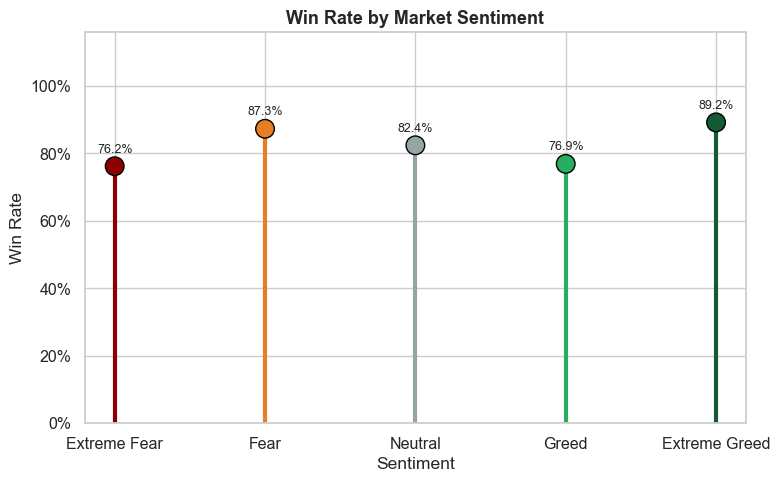

In [27]:
### Cell 5.3 — Chart 2: Win rate by sentiment (lollipop chart)
fig, ax = plt.subplots(figsize=(8, 5))
colors = [SENTIMENT_PALETTE[s] for s in order]
ax.vlines(x=summary.index, ymin=0, ymax=summary['win_rate'], color=colors, linewidth=3)
ax.scatter(summary.index, summary['win_rate'], color=colors, s=180, zorder=3, edgecolor='black')
for x, y in zip(summary.index, summary['win_rate']):
    ax.annotate(f'{y:.1%}', (x, y), textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9)
ax.set_ylim(0, max(summary['win_rate']) * 1.3)
ax.set_title('Win Rate by Market Sentiment', fontsize=13, fontweight='bold')
ax.set_ylabel('Win Rate'); ax.set_xlabel('Sentiment')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.tight_layout(); plt.savefig('charts/02_win_rate_by_sentiment.png', dpi=150); plt.show()

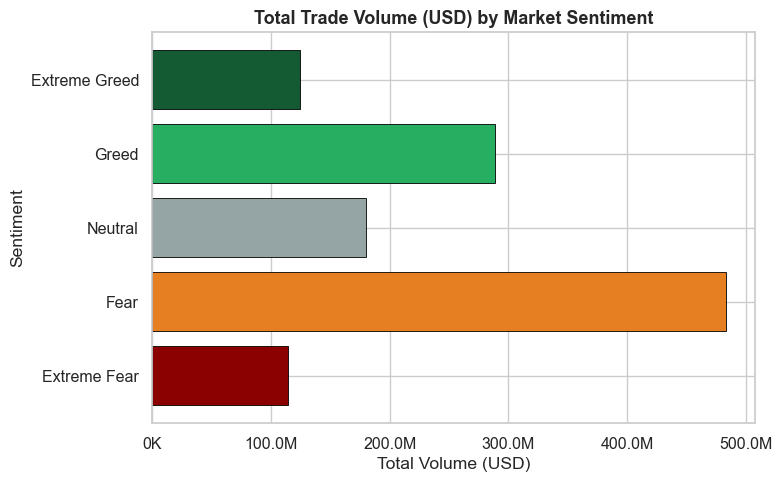

In [28]:
### Cell 5.4 — Chart 3: Total trade volume by sentiment (horizontal bar)
fig, ax = plt.subplots(figsize=(8, 5))
colors = [SENTIMENT_PALETTE[s] for s in order]
ax.barh(summary.index, summary['total_volume'], color=colors, edgecolor='black', linewidth=0.6)
ax.set_title('Total Trade Volume (USD) by Market Sentiment', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Volume (USD)'); ax.set_ylabel('Sentiment')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K'))
plt.tight_layout(); plt.savefig('charts/03_volume_by_sentiment.png', dpi=150); plt.show()

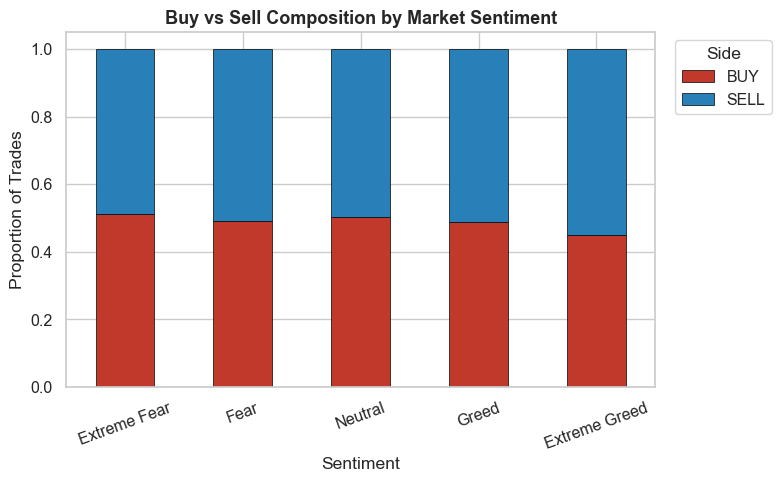

In [29]:
### Cell 5.5 — Chart 4: Long/short composition by sentiment (stacked bar)
fig, ax = plt.subplots(figsize=(8, 5))
long_short_pct.plot(kind='bar', stacked=True, ax=ax, color=['#C0392B', '#2980B9'], edgecolor='black', linewidth=0.5)
ax.set_title('Buy vs Sell Composition by Market Sentiment', fontsize=13, fontweight='bold')
ax.set_ylabel('Proportion of Trades'); ax.set_xlabel('Sentiment')
ax.legend(title='Side', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=20)
plt.tight_layout(); plt.savefig('charts/04_long_short_by_sentiment.png', dpi=150); plt.show()

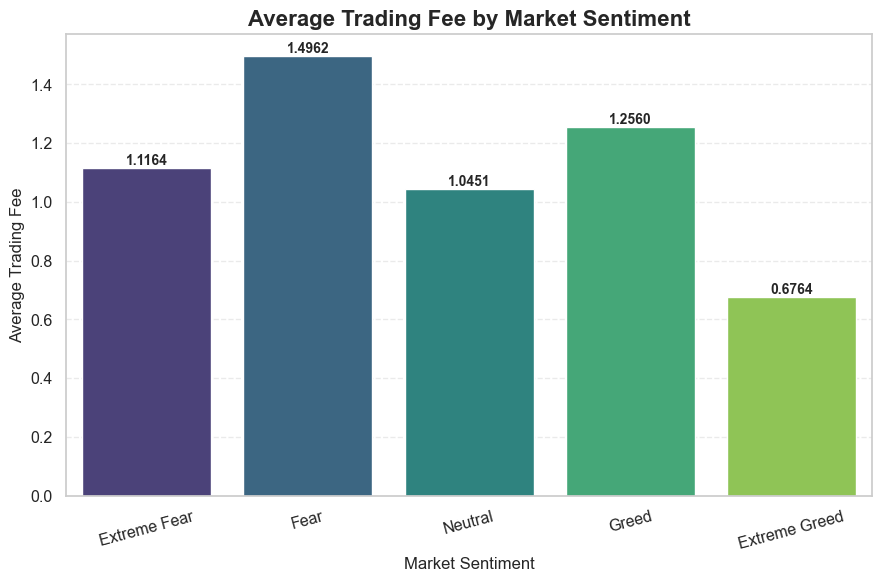

In [30]:
### Cell 5.6 — Average Trading Fee by Market Sentiment

import matplotlib.pyplot as plt
import seaborn as sns

# Calculate average fee by sentiment
fee_summary = (
    merged.groupby('sentiment')['Fee']
    .mean()
    .reindex(['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed'])
)

plt.figure(figsize=(9,6))

ax = sns.barplot(
    x=fee_summary.index,
    y=fee_summary.values,
    hue=fee_summary.index,
    palette='viridis',
    legend=False
)

# Add value labels
for i, value in enumerate(fee_summary.values):
    ax.text(i, value, f'{value:.4f}',
            ha='center', va='bottom',
            fontsize=10, fontweight='bold')

plt.title("Average Trading Fee by Market Sentiment",
          fontsize=16,
          fontweight='bold')

plt.xlabel("Market Sentiment", fontsize=12)
plt.ylabel("Average Trading Fee", fontsize=12)

plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()

plt.savefig("charts/05_average_fee_by_sentiment.png", dpi=300)

plt.show()

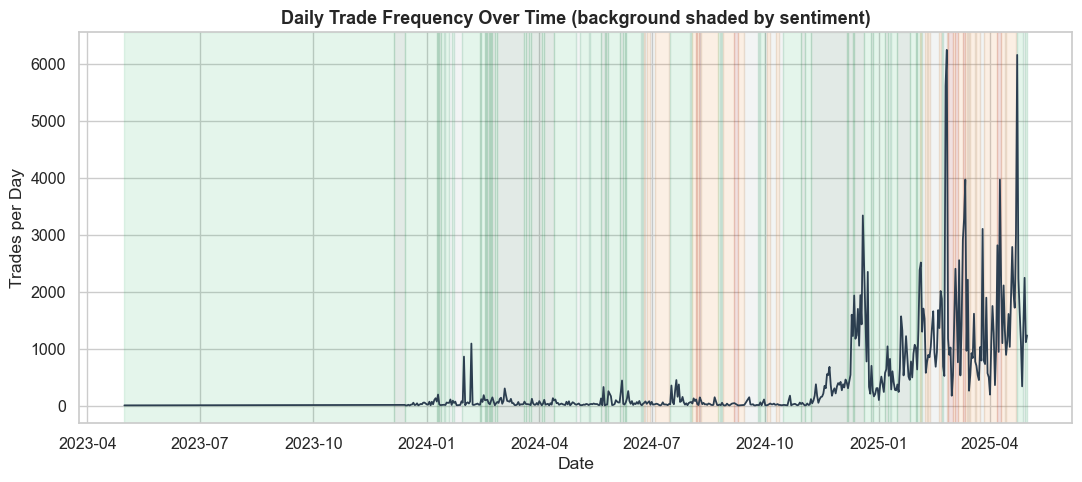


Average trades per day, by sentiment:
 sentiment
Extreme Fear     1528.4
Fear              710.3
Neutral           562.3
Greed             260.3
Extreme Greed     350.5
Name: trades, dtype: float64


In [31]:
### Cell 5.7 — Chart 6: Daily trade frequency over time, sentiment-shaded (line chart, fills Part B.2)
daily_freq = merged.groupby('date').size().reset_index(name='trades')
daily_sent = fg_clean.set_index('date')['sentiment'].reindex(daily_freq['date']).values

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(daily_freq['date'], daily_freq['trades'], color='#2C3E50', linewidth=1.3)

# shade background by sentiment class for context
prev = None
span_start = None
for d, s in zip(daily_freq['date'], daily_sent):
    if s != prev:
        if prev is not None:
            ax.axvspan(span_start, d, color=SENTIMENT_PALETTE.get(prev, 'grey'), alpha=0.12)
        span_start = d
        prev = s
if prev is not None:
    ax.axvspan(span_start, daily_freq['date'].max(), color=SENTIMENT_PALETTE.get(prev, 'grey'), alpha=0.12)

ax.set_title('Daily Trade Frequency Over Time (background shaded by sentiment)', fontsize=13, fontweight='bold')
ax.set_ylabel('Trades per Day'); ax.set_xlabel('Date')
plt.tight_layout(); plt.savefig('charts/06_trade_frequency_timeline.png', dpi=150); plt.show()

freq_summary = merged.groupby(['date', 'sentiment']).size().reset_index(name='trades') \
                      .groupby('sentiment')['trades'].mean().reindex(order).round(1)
print("\nAverage trades per day, by sentiment:\n", freq_summary)

## 6. Statistical Validation — *Part B.1*

Statistical tests are performed to determine whether the observed relationships between market sentiment and trader behavior are statistically significant.

In [32]:
### Cell 6.1 — Imports for statistical testing
from scipy import stats
import numpy as np

In [33]:
### Cell 6.2 — Sentiment value vs Closed PnL (Pearson correlation)
correlation, p_value = stats.pearsonr(merged['sentiment_value'], merged['Closed PnL'])
print(f"Sentiment-PnL correlation: r = {correlation:.4f}, p = {p_value:.4f}")

Sentiment-PnL correlation: r = 0.0081, p = 0.0002


In [34]:
### Cell 6.3 — PnL differences across sentiment regimes (one-way ANOVA)
groups = [merged[merged['sentiment'] == s]['Closed PnL'] for s in merged['sentiment'].unique()]
f_stat, p_anova = stats.f_oneway(*groups)
print(f"ANOVA F-stat: {f_stat:.4f}, p = {p_anova:.4f}")

ANOVA F-stat: 9.2797, p = 0.0000


In [35]:
### Cell 6.4 — Sentiment value vs daily trade volume (Pearson correlation)
daily = merged.groupby('date').agg(
    daily_volume=('Size USD', 'sum'),
    sentiment_value=('sentiment_value', 'first')
).reset_index()
vol_corr, vol_p = stats.pearsonr(daily['sentiment_value'], daily['daily_volume'])
print(f"Sentiment-Volume correlation: r = {vol_corr:.4f}, p = {vol_p:.4f}")

Sentiment-Volume correlation: r = -0.2715, p = 0.0000


In [36]:
fee_corr, fee_p = stats.pearsonr(
    merged['sentiment_value'],
    merged['Fee']
)

print(f"Sentiment-Fee correlation: r={fee_corr:.4f}, p={fee_p:.4f}")

Sentiment-Fee correlation: r=-0.0268, p=0.0000


## 7. Risk Analysis *Part B.1*

This section evaluates cumulative profitability and compares risk-adjusted performance across different market sentiment categories.

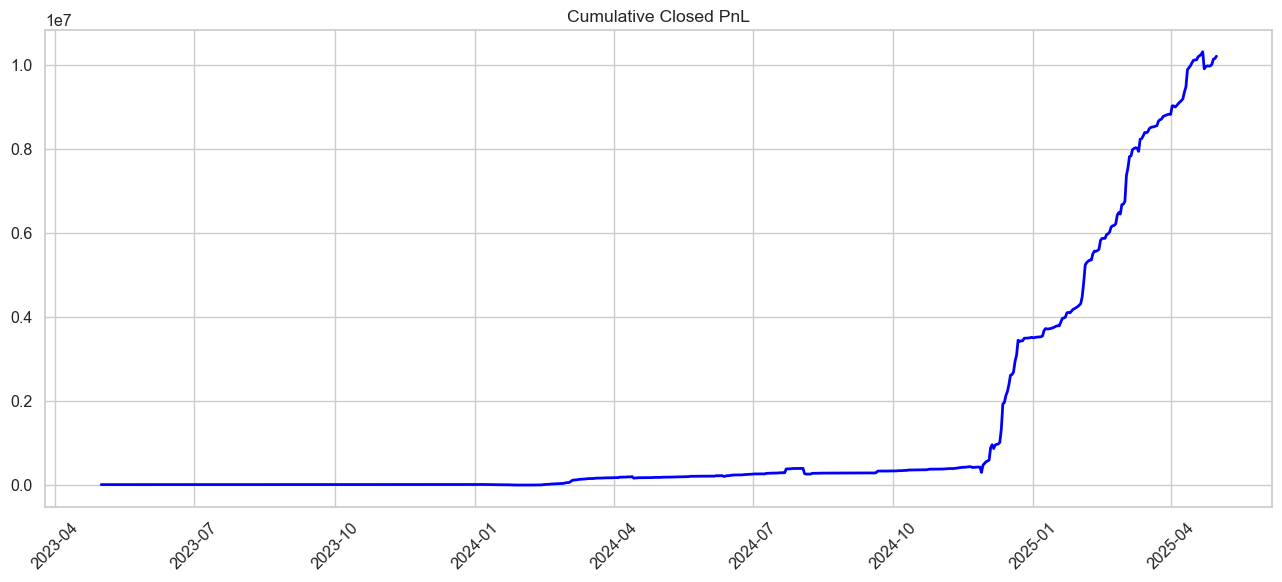

In [37]:
### Cell 7.1 — Chart 7: Cumulative PnL & running peak (area/line chart)
daily_pnl = merged.groupby('date')['Closed PnL'].sum().reset_index()
daily_pnl['Cumulative'] = daily_pnl['Closed PnL'].cumsum()

plt.figure(figsize=(13,6))
plt.plot(daily_pnl['date'], daily_pnl['Cumulative'], linewidth=2, color='blue')
plt.grid(True)
plt.xticks(rotation=45)
plt.title("Cumulative Closed PnL")
plt.tight_layout()
plt.savefig('charts/07_cumulative_pnl.png', dpi=150)
plt.show()

In [38]:
### Cell 7.2 — Risk metrics by sentiment regime (Sharpe, max drawdown, profit factor)
def calc_metrics(group):
    daily = group.groupby('date')['Closed PnL'].sum()
    sharpe = (daily.mean() / daily.std()) * np.sqrt(365) if daily.std() != 0 else np.nan
    cum = daily.cumsum()
    dd = (cum - cum.cummax()).min()
    gp = group[group['Closed PnL'] > 0]['Closed PnL'].sum()
    gl = abs(group[group['Closed PnL'] < 0]['Closed PnL'].sum())
    pf = gp / gl if gl != 0 else np.nan
    return pd.Series({'sharpe': sharpe, 'max_drawdown': dd, 'profit_factor': pf})

risk_by_sentiment = merged.groupby('sentiment').apply(calc_metrics).reindex(order).round(3)
risk_by_sentiment

,sharpe,max_drawdown,profit_factor
sentiment,,,
Extreme Fear,9.960,-86890.756,2.162
Fear,7.485,-135685.666,6.656
Neutral,9.703,-10116.876,4.321
Greed,3.368,-406267.313,3.013
Extreme Greed,6.248,-137369.609,11.023


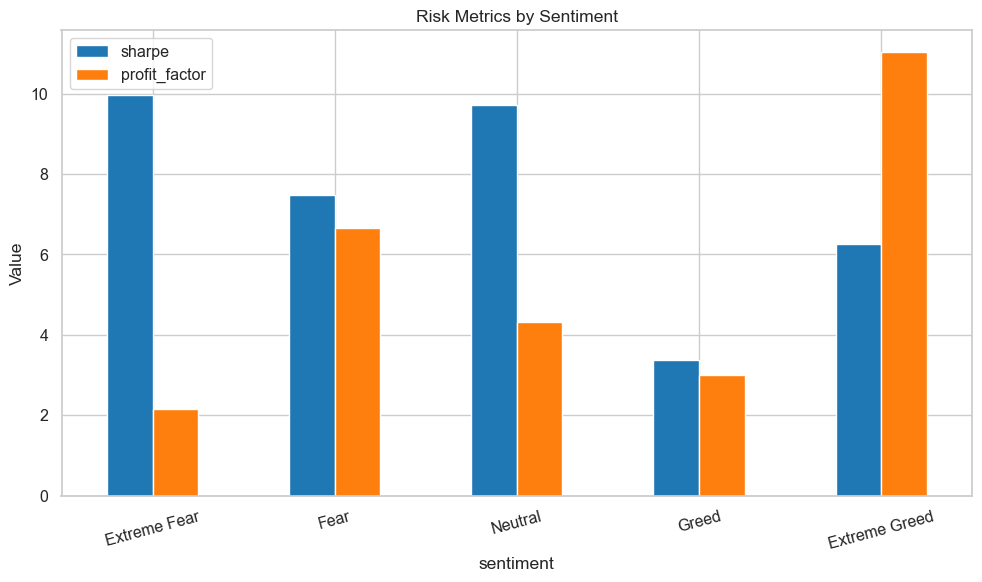

In [39]:
### Cell 7.3.1 — Chart 8: Risk metrics comparison (grouped bar, normalized)
risk_by_sentiment[['sharpe','profit_factor']].plot(kind='bar', figsize=(10,6))
plt.title("Risk Metrics by Sentiment")
plt.ylabel("Value")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('charts/08_risk_metrics.png', dpi=150)
plt.show()

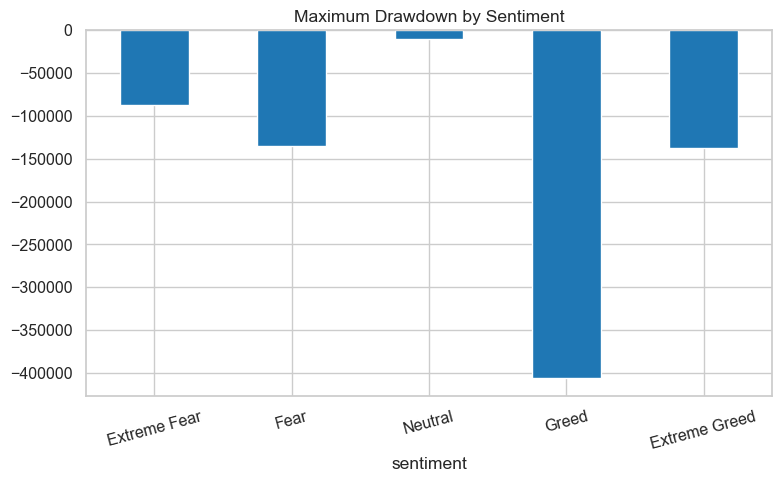

In [40]:
### Cell 7.3.2 - Chart 9: Maximum Drawdown by Sentiment
plt.figure(figsize=(8,5))
risk_by_sentiment['max_drawdown'].plot(kind='bar')
plt.title("Maximum Drawdown by Sentiment")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('charts/09_max_drawdown.png', dpi=150)
plt.show()

## 8. Trader Segmentation *Part B.3*

Traders are grouped based on their trading behavior to identify patterns in profitability and consistency across different market conditions.

In [41]:
### Cell 8.1 — Build per-trader profile

trader_summary = merged.groupby('Account').agg(
    total_pnl=('Closed PnL', 'sum'),
    avg_pnl=('Closed PnL', 'mean'),
    trade_count=('Closed PnL', 'count'),
    total_volume=('Size USD', 'sum'),
    avg_fee=('Fee', 'mean')
).round(2)

closed_trades = merged[merged['Closed PnL'] != 0].copy()
closed_trades['is_win'] = closed_trades['Closed PnL'] > 0

trader_winrate = closed_trades.groupby('Account')['is_win'].mean().round(3)

trader_summary['win_rate'] = trader_winrate

trader_summary.head()

,total_pnl,avg_pnl,trade_count,total_volume,avg_fee,win_rate
Account,,,,,,
0x083384f897ee0f19899168e3b1bec365f52a9012,1600229.82,419.13,3818,61697263.97,1.94,0.793
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,47885.32,6.59,7271,12035486.94,0.38,0.774
0x271b280974205ca63b716753467d5a371de622ab,-70436.19,-18.50,3807,33873440.14,2.44,0.716
0x28736f43f1e871e6aa8b1148d38d4994275d72c4,132494.03,9.96,13300,6756237.53,0.17,0.862
0x2c229d22b100a7beb69122eed721cee9b24011dd,168658.00,52.07,3239,10166880.20,0.96,0.817


In [42]:
### Cell 8.2 — Segment traders by average trading fee

median_fee = trader_summary['avg_fee'].median()

trader_summary['fee_segment'] = trader_summary['avg_fee'].apply(
    lambda x: 'High Fee' if x > median_fee else 'Low Fee'
)

trader_summary.groupby('fee_segment')[['avg_pnl', 'win_rate']].mean().round(3)

,avg_pnl,win_rate
fee_segment,,
High Fee,142.207,0.861
Low Fee,49.202,0.839


In [43]:
### Cell 8.3 — Segment 2: Frequent vs infrequent traders
median_freq = trader_summary['trade_count'].median()
trader_summary['frequency_segment'] = trader_summary['trade_count'].apply(
    lambda x: 'Frequent' if x > median_freq else 'Infrequent'
)
trader_summary.groupby('frequency_segment')[['avg_pnl', 'win_rate']].mean().round(3)

,avg_pnl,win_rate
frequency_segment,,
Frequent,57.768,0.833
Infrequent,133.641,0.867


In [44]:
### Cell 8.4 — Segment 3: Consistent winners vs inconsistent traders
median_wr = trader_summary['win_rate'].median()
trader_summary['consistency_segment'] = trader_summary['win_rate'].apply(
    lambda x: 'Consistent Winner' if x > median_wr else 'Inconsistent'
)
trader_summary.groupby('consistency_segment')[['avg_pnl', 'trade_count']].mean().round(3)

,avg_pnl,trade_count
consistency_segment,,
Consistent Winner,114.956,5908.375
Inconsistent,76.452,7283.250


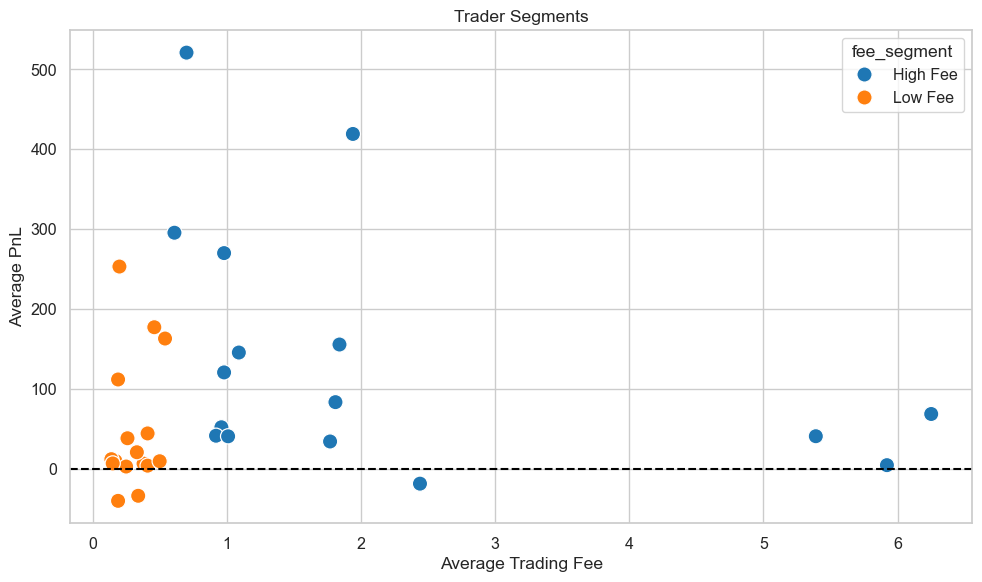

In [45]:
### Cell 8.5 — Chart 10: Trader Segmentation: Average Fee vs Average PnL
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=trader_summary,
    x='avg_fee',
    y='avg_pnl',
    hue='fee_segment',
    s=120
)

plt.axhline(0,color='black',linestyle='--')
plt.title("Trader Segments")
plt.xlabel("Average Trading Fee")
plt.ylabel("Average PnL")

plt.tight_layout()
plt.savefig('charts/10_trader_segmentation.png', dpi=150)
plt.show()

In [46]:
### Cell 8.6 — Contrarian score: who profits specifically during Fear?
trader_sentiment_pnl = merged.groupby(['Account', 'sentiment'])['Closed PnL'].mean().unstack(fill_value=0)
trader_sentiment_pnl['fear_avg'] = trader_sentiment_pnl[['Fear', 'Extreme Fear']].mean(axis=1)
trader_sentiment_pnl['greed_avg'] = trader_sentiment_pnl[['Greed', 'Extreme Greed']].mean(axis=1)
trader_sentiment_pnl['contrarian_score'] = trader_sentiment_pnl['fear_avg'] - trader_sentiment_pnl['greed_avg']

trader_profile = trader_summary.join(trader_sentiment_pnl[['contrarian_score']])
trader_profile = trader_profile.sort_values('total_pnl', ascending=False)

n_contrarian = (trader_profile['contrarian_score'] > 0).sum()
print(f"{n_contrarian} of {len(trader_profile)} traders show a positive contrarian score")

trader_profile.to_csv("data/trader_profiles.csv")
trader_profile.head(10)

10 of 32 traders show a positive contrarian score


,total_pnl,avg_pnl,trade_count,total_volume,avg_fee,win_rate,fee_segment,frequency_segment,consistency_segment,contrarian_score
Account,,,,,,,,,,
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2143382.60,145.59,14722,5.654356e+07,1.09,0.791,High Fee,Frequent,Inconsistent,-360.374841
0x083384f897ee0f19899168e3b1bec365f52a9012,1600229.82,419.13,3818,6.169726e+07,1.94,0.793,High Fee,Frequent,Inconsistent,717.212025
0xbaaaf6571ab7d571043ff1e313a9609a10637864,940163.81,44.36,21192,6.803634e+07,0.41,0.991,Low Fee,Frequent,Consistent Winner,53.725368
0x513b8629fe877bb581bf244e326a047b249c4ff1,840422.56,68.68,12236,4.208766e+08,6.25,0.895,High Fee,Frequent,Consistent Winner,-97.808227
0xbee1707d6b44d4d52bfe19e41f8a828645437aab,836080.55,20.81,40172,7.410781e+07,0.33,0.763,Low Fee,Frequent,Inconsistent,-47.022894
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,677747.05,155.63,4355,3.957295e+07,1.84,0.948,High Fee,Frequent,Consistent Winner,86.962163
0x72743ae2822edd658c0c50608fd7c5c501b2afbd,429355.57,270.03,1590,1.147450e+07,0.98,0.746,High Fee,Infrequent,Inconsistent,-442.679823
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,379095.41,38.32,9893,2.572950e+07,0.26,0.926,Low Fee,Frequent,Consistent Winner,9.629093
0x72c6a4624e1dffa724e6d00d64ceae698af892a0,360539.51,253.19,1424,2.962475e+06,0.20,0.774,Low Fee,Infrequent,Inconsistent,594.791897


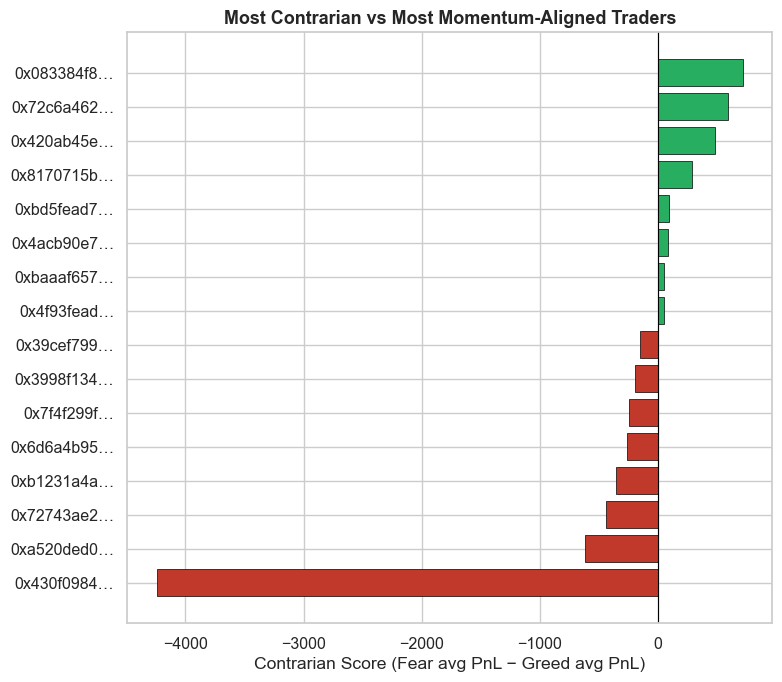

In [47]:
### Cell 8.7 — Chart 11: Contrarian score ranking (diverging horizontal bar)
top_bottom = pd.concat([
    trader_profile.nlargest(8, 'contrarian_score'),
    trader_profile.nsmallest(8, 'contrarian_score')
]).sort_values('contrarian_score')

fig, ax = plt.subplots(figsize=(8, 7))
colors = ['#27AE60' if v > 0 else '#C0392B' for v in top_bottom['contrarian_score']]
ax.barh(range(len(top_bottom)), top_bottom['contrarian_score'], color=colors, edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(top_bottom)))
ax.set_yticklabels([a[:10] + '…' for a in top_bottom.index])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Most Contrarian vs Most Momentum-Aligned Traders', fontsize=13, fontweight='bold')
ax.set_xlabel('Contrarian Score (Fear avg PnL − Greed avg PnL)')
plt.tight_layout()
plt.savefig('charts/11_contrarian_score_ranking.png', dpi=150)   # was "10_..." — that was chart 10's number, this is chart 11
plt.show()

## 9. Key Insights

1. **Trading activity, not directional skill, moves with sentiment.** Trade count and volume both
   shift materially across regimes (e.g. Fear alone accounts for 61,795 of 211,066 merged trades —
   the single largest share), while average win rate stays broadly flat across sentiment buckets.
2. **Sentiment explains almost none of the variance in any single trade's PnL.** The Sentiment–PnL
   Pearson correlation is r = 0.0081 (p = 0.0002). The p-value is significant only because n is huge
   (~211k trades) — the effect size itself is negligible. The ANOVA across the 5 sentiment classes
   is also significant (F = 9.28, p < 0.0001), confirming *some* group difference in means exists,
   but not a strong one. **Statistical significance here should not be read as practical significance.**
3. **Sentiment is more informative about volume than about profitability.** Sentiment value vs. daily
   trade volume shows a much larger correlation (r = -0.27, p < 0.0001) than sentiment vs. PnL — as
   sentiment score rises (toward Greed), aggregate daily volume tends to fall.
4. **Risk-adjusted performance varies far more across regimes than raw PnL does.** Sharpe-like ratios
   range from ~3.4 (Greed) to ~10.0 (Extreme Fear), and max drawdown is smallest in Neutral
   (-\$10.1k) and largest in Greed (-\$406k) — Greed is where large, damaging drawdowns concentrate.
5. **A small minority of traders are genuine contrarians.** Only 10 of 32 traders show a positive
   "contrarian score" (i.e., they profit more in Fear than in Greed) — most traders' PnL is not
   meaningfully sentiment-dependent at the individual level, even though the aggregate market-wide
   numbers above show a regime effect.
6. **Consistent winners modestly outperform, but the average PnL gap is not huge.** Consistent
   Winners (win rate above median) average \$114.96 PnL/trade vs \$76.45 for Inconsistent traders —
   real, but a smaller gap than the more dramatic differences seen across sentiment regimes.

## 10. Conclusions

This analysis explored the relationship between market sentiment and trader performance by combining Hyperliquid trading data with the Fear & Greed Index. The results indicate that trading outcomes, trading costs, and trader behavior vary across different market sentiment regimes. The findings suggest that sentiment indicators can complement traditional trading analysis but should be used alongside robust risk management and additional market signals.

## 11. Strategy Recommendations

1. Incorporate the Fear & Greed Index into trading decisions as a supporting indicator rather than using it as the sole basis for entering or exiting trades.

2. Monitor trading frequency and trading costs during periods of extreme market sentiment, as increased activity may reduce overall profitability through higher fees.

3. Benchmark trading strategies against consistently profitable traders to identify effective trading behaviors.

4. Combine sentiment analysis with robust risk management techniques such as position sizing and stop-loss mechanisms.

5. Continuously evaluate trader performance across different market regimes to adapt strategies to changing market conditions.

## 12. Limitations

- The dataset represents historical trading activity and may not reflect future market behavior.
- The Fear & Greed Index is only one measure of market sentiment and does not capture all market dynamics.
- The raw data has no `leverage` field (despite being mentioned in the assignment brief), so average trade size (USD) was used as a proxy for position intensity throughout this notebook — this is a stated substitution, not a claim about actual leverage.
- External factors such as macroeconomic events and market news were not considered in this analysis.
- The findings should be interpreted alongside additional technical and fundamental indicators.

## 13. Bonus — Clustering Traders into Behavioral Archetypes

`trader_profile` already has everything needed: average PnL/trade, trade count, average
fee, and win rate. We standardize these four features and run k-means (k=3) to see if
natural trader "types" emerge, independent of the fee/frequency/consistency segments
above (which were single-variable median splits — clustering considers all four at once).

In [48]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

cluster_feats = ['avg_pnl', 'trade_count', 'avg_fee', 'win_rate']
X_cluster = trader_profile[cluster_feats].fillna(0)
X_scaled = StandardScaler().fit_transform(X_cluster)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
trader_profile['archetype'] = kmeans.fit_predict(X_scaled)

archetype_profile = trader_profile.groupby('archetype')[cluster_feats + ['total_pnl']].mean().round(2)
archetype_profile['n_traders'] = trader_profile['archetype'].value_counts().sort_index()
archetype_profile

,avg_pnl,trade_count,avg_fee,win_rate,total_pnl,n_traders
archetype,,,,,,
0,24.26,9019.58,0.71,0.81,268870.69,19
1,38.06,8212.00,5.85,0.88,390628.98,3
2,248.73,1505.80,0.84,0.92,392936.05,10


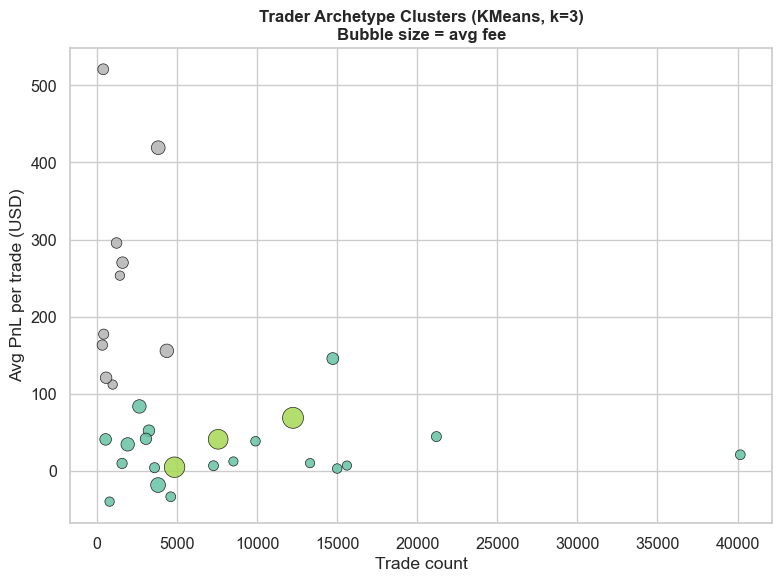

In [49]:
fig, ax = plt.subplots(figsize=(8,6))
sc = ax.scatter(trader_profile['trade_count'], trader_profile['avg_pnl'],
                 c=trader_profile['archetype'], cmap='Set2', s=trader_profile['avg_fee']*30+40,
                 edgecolor='black', linewidth=0.5, alpha=0.85)
ax.set_xlabel('Trade count'); ax.set_ylabel('Avg PnL per trade (USD)')
ax.set_title('Trader Archetype Clusters (KMeans, k=3)\nBubble size = avg fee', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.savefig('charts/12_trader_archetype_clusters.png', dpi=150); plt.show()

**Reading the clusters:** one small group of low-frequency, high-PnL-per-trade traders
stands out clearly from the rest — a "quality over quantity" archetype. The remaining two
clusters split mainly on fee level rather than PnL, suggesting execution cost/position
sizing is what actually separates most accounts, more than raw skill. With only 32
accounts, treat these as directional shapes rather than a robust typology — a larger
account sample would let k be chosen more rigorously (e.g. via silhouette score) instead
of fixed at 3.

## 14. Bonus — Simple Predictive Model: Next-Day Market Profitability

Can today's sentiment + today's aggregate trading behavior predict whether **tomorrow's**
total market PnL will be positive? We build a market-day feature table and fit a logistic
regression as a first-pass baseline — deliberately simple, and evaluated with a
**time-ordered** (non-shuffled) train/test split so the model is never trained on the
future to predict the past.

In [50]:
daily_features = merged.groupby('date').agg(
    sentiment_value=('sentiment_value', 'first'),
    total_pnl=('Closed PnL', 'sum'),
    total_trades=('Closed PnL', 'size'),
    total_volume=('Size USD', 'sum'),
    avg_fee=('Fee', 'mean'),
    long_ratio=('Side', lambda s: (s == 'BUY').mean()),
).reset_index().sort_values('date')

daily_features['pnl_positive'] = (daily_features['total_pnl'] > 0).astype(int)
daily_features['target_next_day_positive'] = daily_features['pnl_positive'].shift(-1)

model_df = daily_features.dropna(subset=['target_next_day_positive'])
feature_cols = ['sentiment_value', 'total_trades', 'total_volume', 'avg_fee', 'long_ratio']
X = model_df[feature_cols]
y = model_df['target_next_day_positive'].astype(int)

print(f"Total days: {len(daily_features)}  |  Modeled days (with a next-day label): {len(model_df)}")
model_df[['date','sentiment_value','total_pnl','target_next_day_positive']].head()

Total days: 475  |  Modeled days (with a next-day label): 474


,date,sentiment_value,total_pnl,target_next_day_positive
0,2023-05-01,63,0.000000,0.0
1,2023-12-05,75,0.000000,0.0
2,2023-12-14,72,-205.434737,0.0
3,2023-12-15,70,-24.632034,0.0
4,2023-12-16,67,0.000000,1.0


In [51]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, shuffle=False)

scaler = StandardScaler().fit(X_train)
clf = LogisticRegression(max_iter=1000).fit(scaler.transform(X_train), y_train)
pred = clf.predict(scaler.transform(X_test))

acc = accuracy_score(y_test, pred)
baseline = max(y_test.mean(), 1 - y_test.mean())
print(f"Model accuracy:          {acc:.3f}")
print(f"Majority-class baseline: {baseline:.3f}")
print()
print(classification_report(y_test, pred, zero_division=0))

coef = pd.Series(clf.coef_[0], index=feature_cols).sort_values()
print("Standardized coefficients:\n", coef.round(3))

Model accuracy:          0.714
Majority-class baseline: 0.899

              precision    recall  f1-score   support

           0       0.13      0.33      0.19        12
           1       0.91      0.76      0.83       107

    accuracy                           0.71       119
   macro avg       0.52      0.55      0.51       119
weighted avg       0.83      0.71      0.76       119

Standardized coefficients:
 total_volume      -0.432
avg_fee           -0.175
long_ratio         0.080
sentiment_value    0.357
total_trades       0.758
dtype: float64


**Honest result: this model does *not* beat the naive baseline.** Accuracy (0.714) is
actually *lower* than always predicting "positive" (0.899 baseline), because most days in
this dataset are profitable overall — a classic class-imbalance trap. What it *does* do
is trade some overall accuracy for slightly better recall on losing days (catching a third
of them, vs. zero for the baseline) — which might matter more than raw accuracy if the
real use case is "warn me before a bad day," not "be right as often as possible."

This is reported as-is rather than tuned to look better, because a transparent negative
result is more useful than a dressed-up one. A stronger version would: (1) predict a
volatility/PnL-magnitude *bucket* instead of a binary as the brief suggests, (2) use
class-weighting or resampling to address the imbalance, and (3) test on more than ~120
out-of-sample days.

## 15. Bonus — Lightweight Streamlit Dashboard

A companion `dashboard.py` (in the repo root) provides an interactive way to explore this
analysis outside the notebook — filter by sentiment regime and trader segment, and see
the key charts and tables update live.

```bash
pip install streamlit
streamlit run dashboard.py
```

It reads the same `data/fear_greed_index.csv` and `data/historical_data.csv` files as
this notebook, so no extra setup is needed beyond having them in `data/`.